<table style="width: 100%; border-collapse: collapse; border: none;">
<tr>
<td style="border: 2px solid #1a2a6c; border-radius: 15px; background-color: #f8f9fa; padding: 40px; text-align: center;">
<h1 style="color: #1a2a6c; margin-bottom: 0px; font-size: 36px; font-family: sans-serif;">
<b>🚀 Predicción de la Demanda Retail</b>
</h1>
<p style="color: #666; font-style: italic; font-size: 18px; margin-top: 10px; font-family: sans-serif;">
Pronóstico de 2.000 series temporales de ventas con modelos globales de machine learning en Python (Darts)
</p>
<hr style="width: 50%; border: 0; border-top: 1px solid #ddd; margin: 20px auto;">
<div style="font-family: sans-serif; font-size: 16px;">
<span style="color: #333;">Autora:</span>
<a href="https://github.com/LunaPerezT" style="color: #3498db; text-decoration: none; font-weight: bold;">Luna Pérez T.</a>
</div>
<br></br>
<div style="background-color: #1a2a6c; color: white; display: inline-block; padding: 10px 10px; border-radius: 5px; font-weight: bold; font-family: sans-serif;">
PARTE 1 : Planteamiento del Problema y Análisis Exploratorio de Datos
</div>
</td>
</tr>
</table>


## **1. Descripción del Problema**

Este proyecto construye un modelo de previsión de ventas diarias para una cadena minorista: **predecir las ventas diarias de cada producto en cada tienda durante el mes de enero de 2016**, a partir de tres años de histórico.

El dataset comprende ventas históricas de **500 productos distintos**, cada uno de ellos caracterizado por:

- **`product_id`**: identificador único del producto.
- **`cat_id`**: categoría a la que pertenece el producto (A, B o C).
- **`subcat_id`**: subcategoría o familia de producto dentro de cada categoría.
- **`store_id`**: punto de venta (4 tiendas en total).

Dado que los 500 productos se venden en las 4 tiendas, el espacio de predicción cubre **2.000 combinaciones producto-tienda**, y para cada una de ellas se deben generar **31 predicciones diarias** (una por cada día de enero de 2016), lo que resulta en un total de **62.000 filas** en el fichero de predicciones.

Además del histórico de ventas (`sales.csv`), se dispone de información sobre el **precio de cada producto por tienda y fecha** (`prices.csv`), lo que permite incorporar el precio como variable exógena en los modelos y capturar posibles efectos de elasticidad precio-demanda.

El fichero de salida tiene las columnas: `id_`, `product_id`, `subcat_id`, `cat_id`, `store_id`, `snapshot_date` y `sales`.

---

## **2.  Inicialización, Carga de Datos & Transformación al Formato Darts**



En primer lugar importaremos las librerías que utilizaremos en este notebook.

In [23]:
import warnings , os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Permite ejecutar el notebook tanto desde notebooks/ como desde la raiz del repositorio.
import os
from pathlib import Path

if not Path('data').is_dir() and Path('..', 'data').is_dir():
    os.chdir('..')
print('Directorio de trabajo:', Path.cwd())

Importamos los datos de ventas

In [24]:
df_raw = pd.read_csv('data/sales.csv', sep=';')
df_raw.head(3)


,id_,cat_id,store_id,subcat_id,product_id,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,...,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-26,2015-12-27,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,A_1_008_1,A,1,1,A_1_008,1.0,1.0,0.0,1.0,0.0,...,20.0,6.0,9.0,0.0,17.0,0.0,8.0,2.0,10.0,7.0
1,A_1_010_1,A,1,1,A_1_010,3.0,3.0,3.0,1.0,1.0,...,1.0,1.0,2.0,0.0,0.0,3.0,0.0,3.0,1.0,0.0
2,A_1_013_1,A,1,1,A_1_013,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 1100 entries, id_ to 2015-12-31
dtypes: float64(1095), int64(2), object(3)
memory usage: 16.8+ MB


In [56]:
META_COLS = ['id_', 'cat_id', 'store_id', 'subcat_id', 'product_id']
DATE_COLS = [c for c in df_raw.columns if c not in META_COLS]


print(f'Filas (series)  : {len(df_raw):,}')
print(f'Fechas          : {DATE_COLS[0]} → {DATE_COLS[-1]}  ({len(DATE_COLS)} días)')
print(f'Productos únicos: {df_raw.product_id.nunique()}')
print(f'Tiendas         : {df_raw.store_id.nunique()}')
print(f'Categorías      : {sorted(df_raw.cat_id.unique())}')
print(f'Subcategorías   : {sorted(df_raw.cat_id.unique())}')


Filas (series)  : 2,000
Fechas          : 2013-01-01 → 2015-12-31  (1095 días)
Productos únicos: 500
Tiendas         : 4
Categorías      : ['A', 'B', 'C']
Subcategorías   : ['A', 'B', 'C']


Como observamos existen un total de 2000 series temporales que van desde el 1 de enero del 2013 hasta el 31 de diciembre del 2015 (tres años de longitud). Estas pertenecen a las ventas de cada uno de los 500 productos en las cuatro tiendas que componen esta empresa.

Dado que las series temporales se recorren en horizontal a través de las columnas vamos adaptar el formato al clásico que encontramos en series temporales, es decir, en vertical, utilizando la función melt.

In [27]:
df_long = df_raw.melt(id_vars=META_COLS, value_vars=DATE_COLS, var_name='ds', value_name='y')
df_long=df_long.assign(ds=pd.to_datetime(df_long['ds']),y=df_long['y'].astype('float32'))
df_long=df_long.sort_values(['id_', 'ds']).rename(columns={'id_': 'unique_id'}).reset_index(drop=True)
print(f'Dimensiones dataframe modificado: {df_long.shape}')
df_long.head(4)

Dimensiones dataframe modificado: (2190000, 7)


,unique_id,cat_id,store_id,subcat_id,product_id,ds,y
0,A_1_008_1,A,1,1,A_1_008,2013-01-01,1.0
1,A_1_008_1,A,1,1,A_1_008,2013-01-02,1.0
2,A_1_008_1,A,1,1,A_1_008,2013-01-03,0.0
3,A_1_008_1,A,1,1,A_1_008,2013-01-04,1.0


In [28]:
df_prices = pd.read_csv('data/prices.csv',sep=";")
df_prices.head(4)

,snapshot_date,product_id,store_id,price
0,2013-01-01,A_1_008,1,1.30
1,2013-01-01,A_1_010,1,3.76
2,2013-01-01,A_1_013,1,3.20
3,2013-01-01,A_1_022,1,8.08


In [29]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2252000 entries, 0 to 2251999
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   snapshot_date  object 
 1   product_id     object 
 2   store_id       int64  
 3   price          float64
dtypes: float64(1), int64(1), object(2)
memory usage: 68.7+ MB


In [30]:
df_prices['snapshot_date'] = pd.to_datetime(df_prices['snapshot_date'])
df_prices['price'] = df_prices['price'].astype('float32')
df_prices['unique_id'] = (df_prices['product_id'].astype(str) + '_' +df_prices['store_id'].astype(str))
df_long = df_long.merge(df_prices[['unique_id', 'snapshot_date', 'price']].rename(columns={'snapshot_date': 'ds'}),on=['unique_id', 'ds'], how='left')
df_long.head(4)


,unique_id,cat_id,store_id,subcat_id,product_id,ds,y,price
0,A_1_008_1,A,1,1,A_1_008,2013-01-01,1.0,1.30
1,A_1_008_1,A,1,1,A_1_008,2013-01-02,1.0,1.42
2,A_1_008_1,A,1,1,A_1_008,2013-01-03,0.0,1.69
3,A_1_008_1,A,1,1,A_1_008,2013-01-04,1.0,1.08


In [31]:
df_long.isnull().sum()

unique_id     0
cat_id        0
store_id      0
subcat_id     0
product_id    0
ds            0
y             0
price         0
dtype: int64

## **3. Análisis Exploratorio de Datos (EDA)**

Antes de construir cualquier modelo, es fundamental comprender la naturaleza y estructura de los datos. En esta sección se llevará a cabo un análisis exploratorio con los siguientes objetivos:

- **Inspección general del dataset**: rango histórico de los datos a distintas escalas y primeras estadísticas descriptivas.
- **Distribución de ventas**: análisis de la distribución de las ventas a nivel global, por categoría, subcategoría y tienda, para detectar asimetrías, outliers o comportamientos extremos.
- **Evolución temporal**: visualización de las series temporales agregadas para identificar tendencias globales, estacionalidad semanal y efectos de calendario (festivos, fin de mes, etc.).
- **Análisis por segmento**: comparación del comportamiento de ventas entre categorías (`cat_id`), subcategorías (`subcat_id`) y tiendas (`store_id`).
- **Relación precio-demanda**: exploración de la correlación entre variaciones de precio y volumen de ventas, tanto a nivel global como por producto.


In [32]:
y_vals = df_long['y'].values

print('═'*55)
print('  ESTADÍSTICAS GLOBALES DE VENTAS DIARIAS')
print('═'*55)
print(f'  Observaciones totales : {len(y_vals)}')
print(f'  Series temporales     : {df_long.unique_id.nunique()}')
print(f'  Media                 : {y_vals.mean()}')
print(f'  Mediana               : {np.median(y_vals)}')
print(f'  Std                   : {y_vals.std()}')
print(f'  P25 / P75 / P99       : {np.percentile(y_vals,25)} / {np.percentile(y_vals,75)} / {np.percentile(y_vals,99)}')
print(f'  Máximo                : {y_vals.max()}')
print(f'  % Ceros               : {(y_vals==0).mean()*100}%')
print(f'  Sesgo (skewness)      : {stats.skew(y_vals)}')
print(f'  Curtosis              : {stats.kurtosis(y_vals)}')
print('═'*55)


═══════════════════════════════════════════════════════
  ESTADÍSTICAS GLOBALES DE VENTAS DIARIAS
═══════════════════════════════════════════════════════
  Observaciones totales : 2190000
  Series temporales     : 2000
  Media                 : 2.8050200939178467
  Mediana               : 1.0
  Std                   : 5.535671234130859
  P25 / P75 / P99       : 0.0 / 3.0 / 26.0
  Máximo                : 356.0
  % Ceros               : 29.44219178082192%
  Sesgo (skewness)      : 7.589690208435059
  Curtosis              : 122.44192504882812
═══════════════════════════════════════════════════════


En esta sección estableceremos una serie de features en nuestro dataset principal que nos ayudaran a representar los datos en este notebook y después a entrenar el modelo. Además estableceremos una serie de ajustes y una carpeta donde se guardaran todas las figuras de esta sección. En primer lugar representaremos los valores de ventas del dataset, excluyendo el 0.


In [33]:
df_long['dow']   = df_long['ds'].dt.dayofweek
df_long['month'] = df_long['ds'].dt.month
df_long['year']  = df_long['ds'].dt.year
df_long['doy']   = df_long['ds'].dt.dayofyear

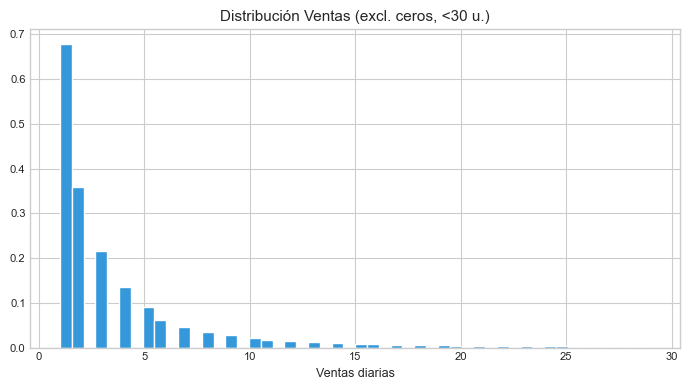

In [34]:
os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'axes.titlesize':11,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8})

fig, ax = plt.subplots(figsize=(7, 4))
y_nz = y_vals[(y_vals > 0) & (y_vals < 30)]
ax.hist(y_nz, bins=50, color='#3498DB', edgecolor='white', density=True)
ax.set_title('Distribución Ventas (excl. ceros, <30 u.)')
ax.set_xlabel('Ventas diarias')
plt.tight_layout()
plt.savefig('outputs/eda_01_distribucion_ventas.png', dpi=130, bbox_inches='tight')
plt.show()

Como observamos, la distribución de las ventas muestra uan gran asimetría hacia la derecha, concentrando la mayoría de sus valores en 1

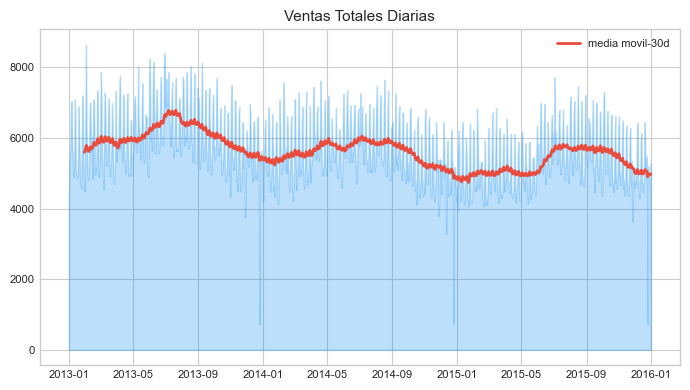

In [35]:
daily = df_long.groupby('ds')['y'].sum()
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(daily.index, daily.values, alpha=0.3, color='#2196F3')
ax.plot(daily.index, daily.rolling(30).mean(), color='#E74C3C', lw=2, label='media movil-30d')
ax.set_title('Ventas Totales Diarias')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_02_ventas_diarias.png', dpi=130, bbox_inches='tight')
plt.show()

Como observamos existe una periodicidad anual en la suma total de las ventas de todas la tiendas, incluso todos los años observamos un mínimo en torno a un día de las navidades.

In [36]:
df_long.groupby('ds')['y'].sum().sort_values()[:3]

ds
2013-12-25    719.0
2015-12-25    721.0
2014-12-25    745.0
Name: y, dtype: float32

En concreto el día de navidad siempre existe una bajada de las ventas de todos los productos. Por ello será muy interesante incluir covariables que muestren periodicidad anual, y podríamos considerar marcar esta fecha en concreto de alguna forma para que el modelo aprenda esta bajada de las ventas.

Para continuar, mostraremos un boxblot que represente la distribución de la ventas en función de la categoría del producto.

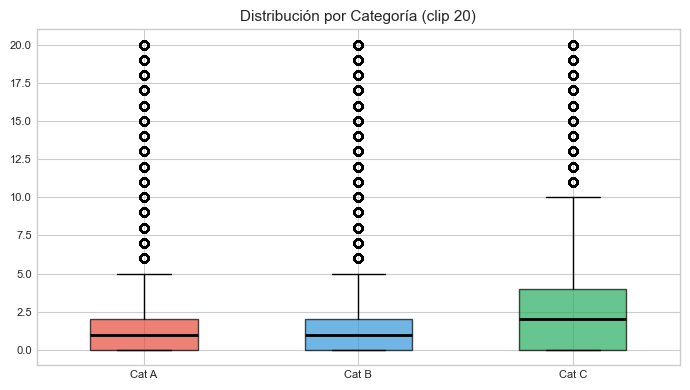

In [37]:
COLORS=dict(A='#E74C3C', B='#3498DB', C='#27AE60')

fig, ax = plt.subplots(figsize=(7, 4))
for i, (cat, grp) in enumerate(df_long.groupby('cat_id')['y']):
    ax.boxplot(grp.clip(0, 20), positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=COLORS[str(cat)], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Cat A', 'Cat B', 'Cat C'])
ax.set_title('Distribución por Categoría (clip 20)')
plt.tight_layout()
plt.savefig('outputs/eda_03_boxplot_categorias.png', dpi=130, bbox_inches='tight')
plt.show()

Observamos que la mediana se situa en torno a una venta por día excepto en el caso de la categoría C. Cabe destacar que existen gran cantidad de outliers en las ventas diarías. Existen productors de todas las categorías que a veces alcanzan 20 ventas diarías.

A continuación representaremos la distribución de los porcentajes de 0 en las series temporales que componen las ventas de cada uno de los productos en cada tienda. Para ello usaremos una gráfica de tipo histograma.

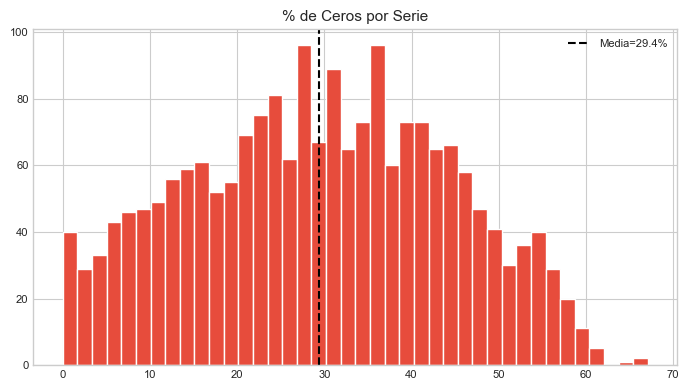

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
zero_by_series = df_long.groupby('unique_id')['y'].apply(lambda x: (x == 0).mean() * 100)
ax.hist(zero_by_series, bins=40, color='#E74C3C', edgecolor='white')
ax.axvline(zero_by_series.mean(), color='black', ls='--',
           label=f'Media={zero_by_series.mean():.1f}%')
ax.set_title('% de Ceros por Serie')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_04_ceros_por_serie.png', dpi=130, bbox_inches='tight')
plt.show()

El porcentaje de 0's que componen las distintas series temporales de los distintos productos se sitúa de media en un 29.4%, llegando en algunos casos hasta el 65%. Esto implicara cierta dificultad en la predicción. Teniendo esto en cuenta podremos utilizar tanto métricas de evaluación como funciones de pérdida que sean adaptadas a este escenario de inestabilidad y alta presencia de 0.

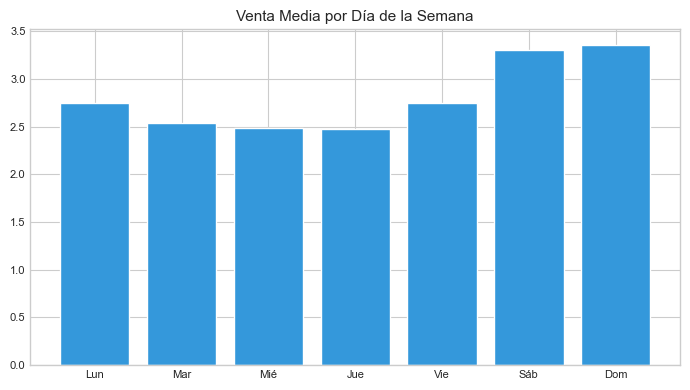

In [39]:
DAYS  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, ax = plt.subplots(figsize=(7, 4))
dow_mean = df_long.groupby('dow')['y'].mean()
ax.bar(range(7), dow_mean.values, color='#3498DB', edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Venta Media por Día de la Semana')
plt.tight_layout()
plt.savefig('outputs/eda_05_media_dia_semana.png', dpi=130, bbox_inches='tight')
plt.show()

Las ventas siguen un patrón cíclico semana relevante. Esta oscila alcanzando maximo el domingo, seguido del sábado y lunes, y alcanzando mínimos el jueves, seguido del miercoles.

A continuación representaremos la media de las ventas, en este caso en función del mes.

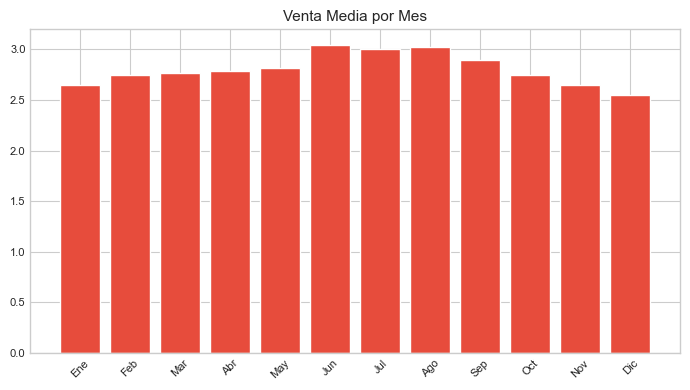

In [40]:
MONTHS= ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(7, 4))
month_mean = df_long.groupby('month')['y'].mean()
ax.bar(range(12), month_mean.values, color='#E74C3C', edgecolor='white')
ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS, rotation=45)
ax.set_title('Venta Media por Mes')
plt.tight_layout()
plt.savefig('outputs/eda_06_media_mes.png', dpi=130, bbox_inches='tight')
plt.show()

Ya hemos mencionado que existe un patrón cíclico anual de las ventas, alcanzando valores culmen en verano (Junio-Julio) y mínimos en Diciembre.

A continuacíon representaremos la media de ventas en los distintos meses y días de la semana, utilizando un mapa de calor. 

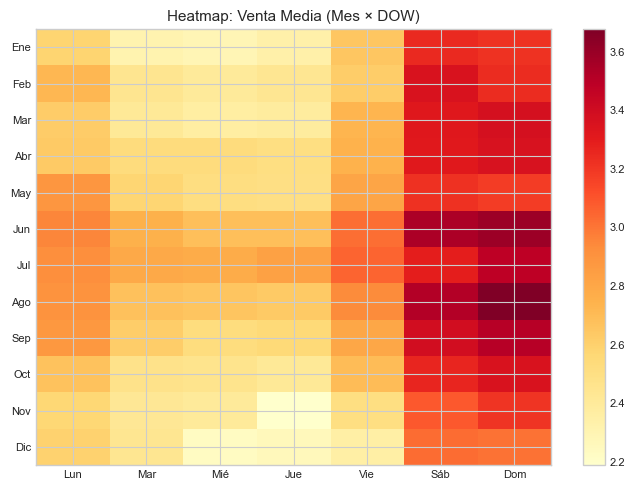

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
heat = df_long.groupby(['month','dow'])['y'].mean().unstack()
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(12))
ax.set_yticklabels(MONTHS)
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Heatmap: Venta Media (Mes × DOW)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('outputs/eda_07_heatmap_mes_dow.png', dpi=130, bbox_inches='tight')
plt.show()

En esta gráfica vemos un aumento de las ventas media diarías especialemtne los fines de semana yen especial de verano, siendo las más altas las que encontramos los domingos de agosto.

In [42]:
print('\n=== Media de ventas por CATEGORÍA × TIENDA ===')
print(df_long.pivot_table('y', index='cat_id', columns='store_id', aggfunc='mean').round(3))



=== Media de ventas por CATEGORÍA × TIENDA ===
store_id      1      2      3      4
cat_id                              
A         2.588  1.620  2.587  1.901
B         1.592  1.750  3.069  0.961
C         4.076  2.814  5.476  2.303


La media de ventas son mucho mayores de productos de la categoría C, especialmente en la tienda con id 3, la cual es la que obtiene más ventas

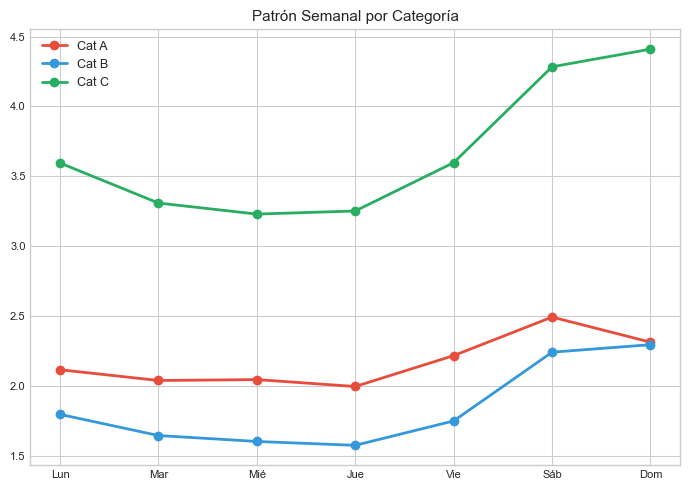

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
for cat, grp in df_long.groupby('cat_id'):
    dm = grp.groupby('dow')['y'].mean()
    ax.plot(range(7), dm.values, marker='o', label=f'Cat {cat}',color=COLORS[str(cat)], lw=2)
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Patrón Semanal por Categoría')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/eda_08_patron_semanal_categoria.png', dpi=130, bbox_inches='tight')
plt.show()

Al representar la distribución de la media de ventas por categoría a lo largo de los dias de la semana, se muestran tendencias parecidas, aunque las ventas de la categoría C tienen un cierto incremento los domingos, siendo en general mayores durante toda la semana.

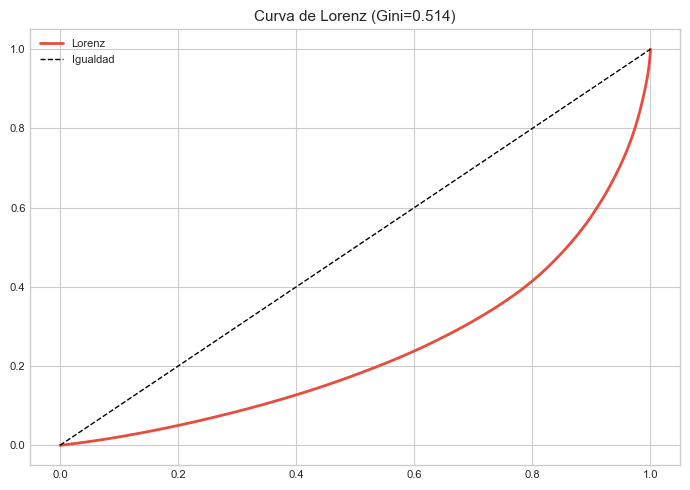

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
st = df_long.groupby('unique_id')['y'].sum().sort_values()
lx = np.linspace(0, 1, len(st))
ly = np.cumsum(st.values) / st.sum()
gini = 1 - 2 * np.trapz(ly, lx)
ax.plot(lx, ly, color='#E74C3C', lw=2, label='Lorenz')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Igualdad')
ax.set_title(f'Curva de Lorenz (Gini={gini:.3f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_09_curva_lorenz.png', dpi=130, bbox_inches='tight')
plt.show()

Como podemos observar tanto la curva de Lorenz como el Gini nos muestra una concentración moderada de las ventas. El gini se mueve entre 0 (desigualdad total, un solo producto se vende) y 1 (igualdad total, todos los productos tienen las mismas ventas). En nuestro caso se encuentra en la 0.514, la mitad, tendremos series temporales que muestran unas mayores ventas, y otras unas menores, pero se encuentran medianamente concentradas. 

A continuación estudiaremos las funciones de autocorrelación (*ACF*, de sus siglas en inglés) y autocorrelación parcial (*PACF*)

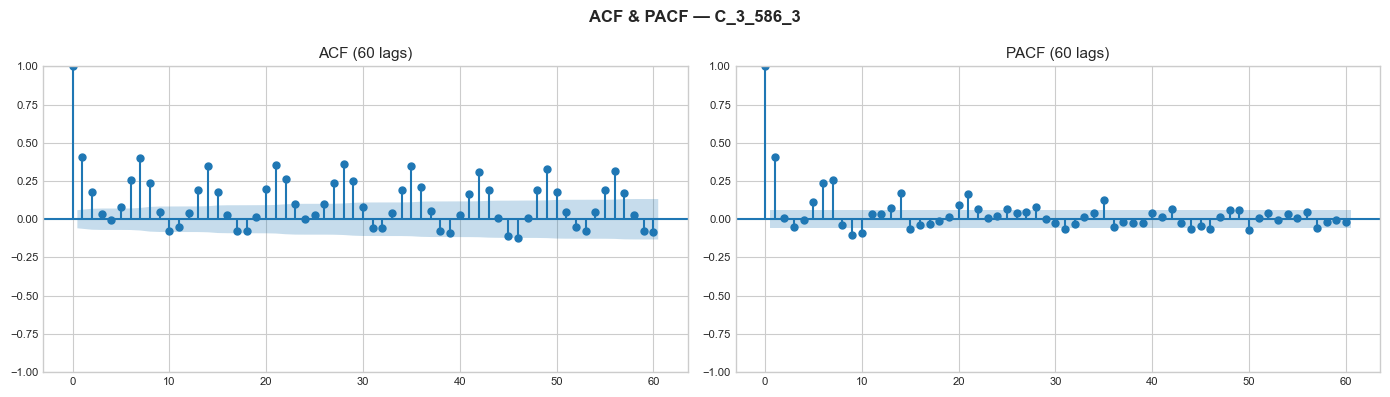

In [45]:
top_uid = df_long.groupby('unique_id')['y'].sum().idxmax()
s_top   = df_long[df_long['unique_id']==top_uid].sort_values('ds')['y'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'ACF & PACF — {top_uid}', fontweight='bold')
plot_acf( s_top, lags=60, ax=axes[0], title='ACF (60 lags)')
plot_pacf(s_top, lags=60, ax=axes[1], title='PACF (60 lags)', method='ywm')
plt.tight_layout()
plt.savefig('outputs/eda_10_acf_pacf_60.png', dpi=130, bbox_inches='tight')
plt.show()


En una ventana de 60 días podemos observar un patrón cíclico principalmente semanal tanto en ACF como en PACF. Vemos principalmente que ACF sigue siendo significativamente alto en los lags v 1, 2, 7, 14, 21, 28, 35, 42, 49, y 56. Por ello sería interesante probar con estos lags durante el entrenamiento del modelo.

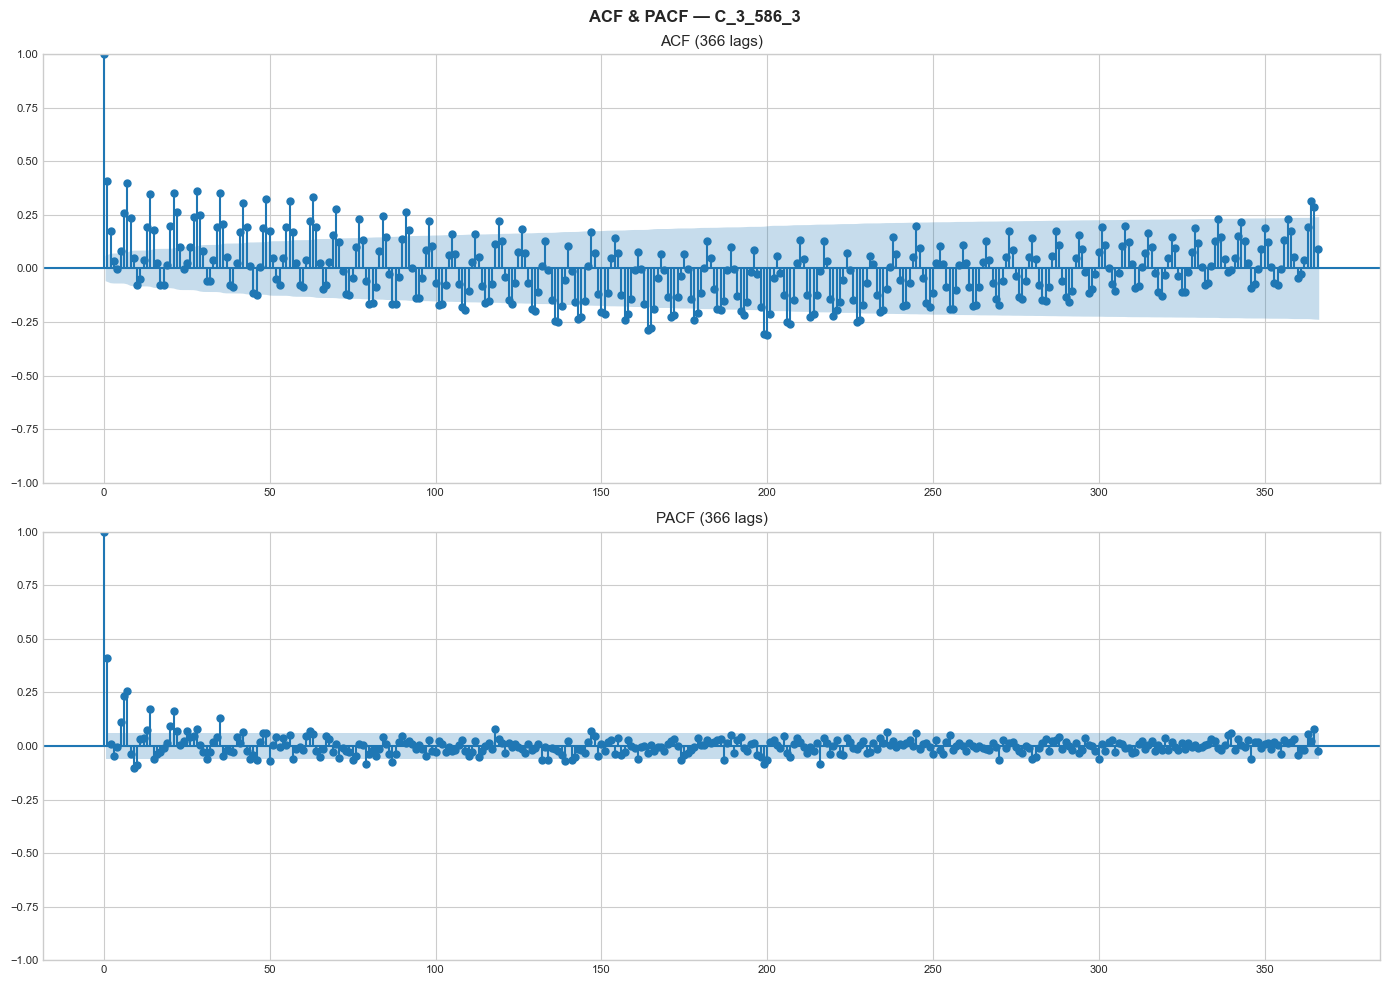

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'ACF & PACF — {top_uid}', fontweight='bold')
plot_acf( s_top, lags=366, ax=axes[0], title='ACF (366 lags)')
plot_pacf(s_top, lags=366, ax=axes[1], title='PACF (366 lags)', method='ywm')
plt.tight_layout()
plt.savefig('outputs/eda_11_acf_pacf_366.png', dpi=130, bbox_inches='tight')
plt.show()

Si extendemos la ventana a 366 días podemos observar que tanto la PACF como la ACF son significativamente altas en algunos puntos que llegan hasta los 120 días. También observamos que existe un cierto patrón ciclíco anual, por lo que tendremos que incluir algunas covariables con patrones cíclicos que codifiquen los meses y años, de forma que el modelo pueda aprender de estos patrones.

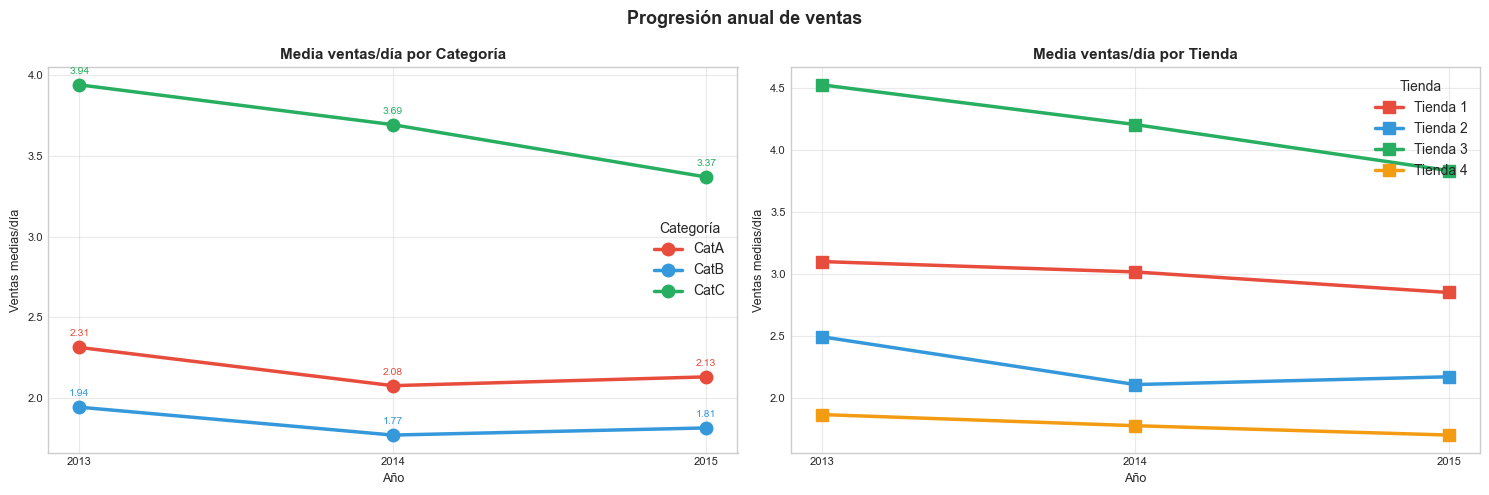

In [47]:
annual_cat = (df_long.assign(year=lambda x: x['ds'].dt.year).groupby(['year','cat_id'])['y'].mean().reset_index())
annual_store = (df_long.assign(year=lambda x: x['ds'].dt.year).groupby(['year','store_id'])['y'].mean().reset_index())
store_palette = ['#E74C3C','#3498DB','#27AE60','#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Progresión anual de ventas',fontsize=13, fontweight='bold')

ax = axes[0]
for cat, grp in annual_cat.groupby('cat_id'):
    ax.plot(grp['year'], grp['y'], marker='o', label=f'Cat{cat}',color=COLORS[cat], linewidth=2.5, markersize=9)
    for _, row in grp.iterrows():
        ax.annotate(f'{row["y"]:.2f}', (row['year'], row['y']),textcoords='offset points', xytext=(0, 8),fontsize=7.5, ha='center', color=COLORS[row['cat_id']])
ax.set_title('Media ventas/día por Categoría', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Ventas medias/día')
ax.set_xticks([2013, 2014, 2015])
ax.legend(title='Categoría'); ax.grid(True, alpha=0.4)

ax = axes[1]
for (sid, grp), col in zip(annual_store.groupby('store_id'), store_palette):
    ax.plot(grp['year'], grp['y'], marker='s', label=f'Tienda {sid}',color=col, linewidth=2.5, markersize=9)
ax.set_title('Media ventas/día por Tienda', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Ventas medias/día')
ax.set_xticks([2013, 2014, 2015])
ax.legend(title='Tienda'); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/eda_12_progresion_anual_de_ventas.png', dpi=130, bbox_inches='tight')
plt.show()


Es interesante destacar que existen tendencias distintas entre las distintas categorías, aunque otras si que comparten rasgos. Po ello utilizar modelos que predigan de forma independiente cada uno de las series temporales de los productos, es decir, utilizar 2000 modelos locales, además de ser una estrategia engorrosa, no capturaría la complejidad de las interacciones de las distintas series entre si. 

Para observar si estos patrones se observan con *más resolución* representaremos las ventas medias/día, por categoría y tienda en cada uno de los meses.

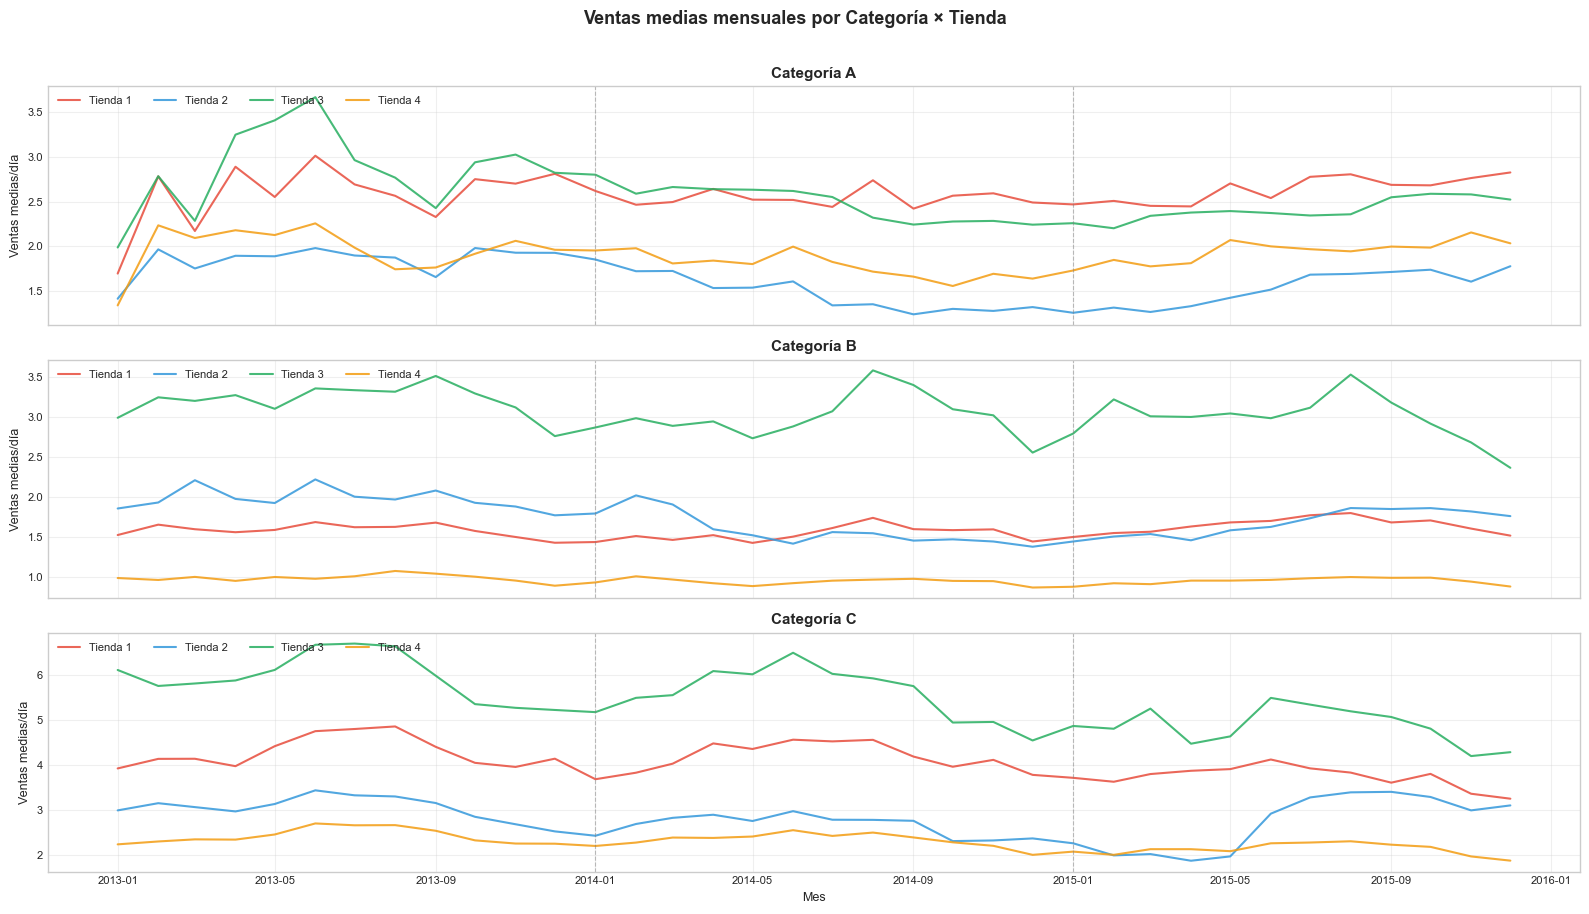

In [48]:
monthly_cat_store = (df_long.assign(ym=lambda x: x['ds'].dt.to_period('M').astype(str))
    .groupby(['ym','cat_id','store_id'])['y'].mean().reset_index()
    .assign(ym_dt=lambda x: pd.to_datetime(x['ym']))
    .sort_values('ym_dt'))
cats = ["A","B","C"]

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Ventas medias mensuales por Categoría × Tienda',fontsize=13, fontweight='bold', y=1.01)

for ax, cat in zip(axes, cats):
    sub = monthly_cat_store[monthly_cat_store['cat_id'] == cat]
    for sid, col in zip(sorted(df_long['store_id'].unique()), store_palette):
        s2 = sub[sub['store_id'] == sid].sort_values('ym_dt')
        ax.plot(s2['ym_dt'], s2['y'], label=f'Tienda {sid}',color=col, linewidth=1.5, alpha=0.85)
    ax.set_title(f'Categoría {cat}', fontweight='bold')
    ax.set_ylabel('Ventas medias/día')
    ax.legend(ncol=4, fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    for yr in [2014, 2015]:
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',linestyle='--', linewidth=0.8, alpha=0.5)
axes[-1].set_xlabel('Mes')
plt.tight_layout()
plt.savefig('outputs/eda_13_progresion_mensual_de_ventas_categoria-tienda.png', dpi=130, bbox_inches='tight')
plt.show()

Aquí de nuevo vemos de forma mucho más grafica lo que comentabamos anteriormente, existen cierta independencia y cierta dependencia de cada una de las series entre sí. Aunque en cada tienda y cada categoría se muestran diferencia en el total y en la forma que varía, todas ellas comparten patrones entre sí, especialmente si pertencen a la misma categoría, o tienda. Por ello es importante que nuestro modelo capture toda esta complejidad.

Por último, representaremos la relación entre las ventas y el precio, utilizando lo que conocemos como un hexbin. Esta gráfica representa la densidad de registros observados en esa combinación de ventas y precio. De esta forma, se pintarán las relaciones entre ambas variables.

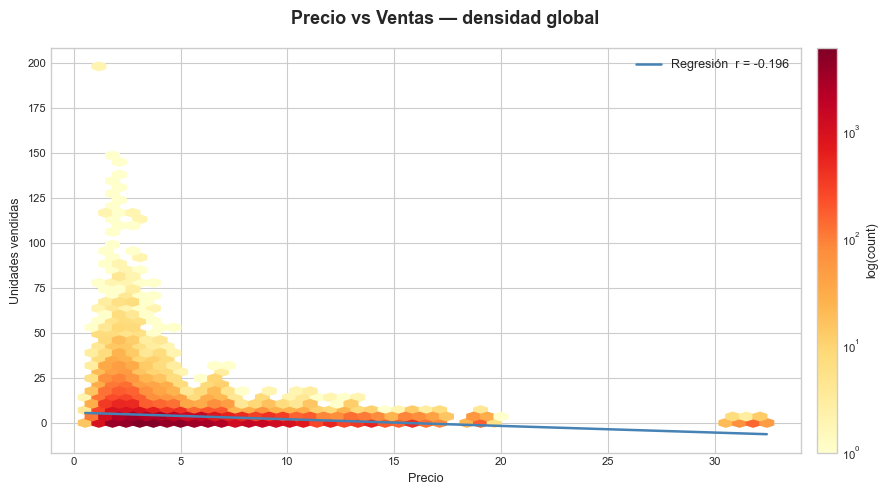

In [50]:
df_p    = df_long.dropna(subset=['price'])
sample1 = df_p.sample(min(80_000, len(df_p)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Precio vs Ventas — densidad global', fontweight='bold', fontsize=13)

hb = ax.hexbin(sample1['price'], sample1['y'], gridsize=50, cmap='YlOrRd', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('log(count)', fontsize=9)

m_lr = (sample1['price'] > 0) & (sample1['y'] > 0)
sl, ic, r_gl, *_ = stats.linregress(sample1.loc[m_lr, 'price'], sample1.loc[m_lr, 'y'])
xl = np.linspace(sample1['price'].min(), sample1['price'].max(), 100)
ax.plot(xl, sl * xl + ic, color='steelblue', lw=1.8, label=f'Regresión  r = {r_gl:.3f}')
ax.set_xlabel('Precio'); ax.set_ylabel('Unidades vendidas')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/eda_14_hexbin_precio.png', dpi=150, bbox_inches='tight')
plt.show()

Como vemos la correlación entre las variables es levemente negativa, lo que muestra un aumento de las ventas a más barato es el producto. Por ello será interesante introducir esta covariable en los casos que sea posible.

---

## **4. Conclusiones y Próximos Pasos**

A lo largo de este notebook hemos realizado un análisis exploratorio exhaustivo de las **2.000 series temporales** que componen el dataset de ventas (500 productos × 4 tiendas), cubriendo el período 2013–2015. A continuación se recogen los hallazgos más relevantes y las decisiones de modelado que se derivan de ellos.


###  Hallazgos clave del EDA

| Aspecto | Hallazgo | Implicación para el modelo |
|---|---|---|
| **Distribución** | Fuerte asimetría positiva, moda en 1 ud./día | Evitar métricas sensibles a outliers (e.g. MSE puro) |
| **Ceros** | Media del 29.4% de ceros por serie, hasta 65% en algunos productos | Considerar modelos o métricas adaptadas a demanda intermitente |
| **Estacionalidad semanal** | Pico domingo-sábado, mínimo miércoles-jueves | Incluir `day_of_week` como covariable; lags 7, 14, 21, 28 |
| **Estacionalidad anual** | Pico en junio-julio, mínimo en diciembre | Incluir `month` y `day_of_year`; flag especial para Navidad |
| **ACF/PACF** | Dependencias significativas hasta lag 56 (semanal) y ~120 (anual) | Ventanas de lags y medias móviles de hasta 4 semanas |
| **Categoría C** | Ventas sistemáticamente superiores, especialmente en Tienda 3 | `cat_id` y `store_id` como covariables estáticas |
| **Concentración** | Gini = 0.514 (concentración moderada) | No es necesario un tratamiento diferenciado masivo por volumen |
| **Precio** | Correlación débil con ventas a nivel global | Incluir precio como covariable exógena, no como predictor principal |



###  Decisiones de preprocesamiento para el siguiente notebook

Con base en los hallazgos anteriores, el preprocesamiento que se llevará a cabo en el **Notebook 2** seguirá estas líneas:

1. **Ingeniería de características temporales**: `day_of_week`, `month`, `day_of_year`, `week_of_year`, flag de fin de semana y flag de día de Navidad (25 de diciembre).
2. **Variables de lag**: lags de ventas en $t-7$, $t-14$, $t-21$ y $t-28$ días para capturar la estacionalidad semanal identificada en la ACF.
3. **Medias móviles**: media y desviación típica de ventas en ventanas de 7, 14 y 28 días.
4. **Variables de precio**: precio actual, variación porcentual respecto a la semana anterior ($\Delta\%$ WoW) y precio relativo respecto a la media histórica del producto.
5. **Codificación de categóricas**: `cat_id`, `subcat_id` y `store_id` mediante label encoding, dado que los modelos de gradient boosting que se emplearán gestionan bien este tipo de codificación.
6. **División temporal train/validación**: se reservará **diciembre de 2015** como conjunto de validación, preservando el orden temporal y simulando el escenario real de predicción del mes siguiente.

---


Para avanzar en el siguiente notebook guardaremos el dataframe que hemos adaptado a formato largo y unido a los precios en formato parquet, para que guarde todo los dtypes y cambios que hemos realizado.

In [54]:
df_long.to_parquet('./data/preprocessed_data.parquet', index=False)